**UPLOAD DATASET**

**Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, precision_recall_fscore_support
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

**Confirm Imports**

In [3]:
print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully!")


TensorFlow version: 2.19.0
All libraries imported successfully!


**Load Dataset & Rename Columns**

In [6]:
# ── Load the dataset (Colab stores uploads in /content/) ──────
df = pd.read_csv('/content/career_recommender.csv')

# Rename columns to short, clean names
df.columns = [
    'Name', 'Gender', 'UG_Course', 'UG_Specialization',
    'Interests', 'Skills', 'CGPA', 'Has_Certification',
    'Cert_Title', 'Is_Working', 'Job_Title', 'Masters'
]

print("=" * 55)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 55)
print(f"Shape          : {df.shape}")
print(f"Total students : {len(df)}")
print(f"\nMissing values :\n{df.isnull().sum()}")
df.head(3)

DATASET LOADED SUCCESSFULLY
Shape          : (1195, 12)
Total students : 1195

Missing values :
Name                   0
Gender                 0
UG_Course              0
UG_Specialization      0
Interests              0
Skills                 1
CGPA                   0
Has_Certification      0
Cert_Title             1
Is_Working             0
Job_Title            296
Masters              726
dtype: int64


,Name,Gender,UG_Course,UG_Specialization,Interests,Skills,CGPA,Has_Certification,Cert_Title,Is_Working,Job_Title,Masters
0,A.Uha Priya,Female,B.Sc,Computer Applications,Cloud computing,Python;SQL;Java,85,Yes,"Linux,Git",Yes,Software,MCA
1,Aadil,Male,B.E,Computer Science Engineering,Technology,"Critical Thinking, Analytic Thinking, SQL, Pro...",66.5,Yes,Microsoft certification,Yes,Computer Software Engineer,NaN
2,Aakriti,Female,BA,Psychology,Understand human behaviour,People management;Communication skills,64.6,Yes,Resilience psychology,No,NaN,NaN


**Define Career Grouping Function**

In [15]:
def group_career(title):
    """Maps a raw job title string to one of 6 career categories."""
    if pd.isna(title):
        return None
    t = str(title).lower().strip()

    # 1. Student / Fresher (not yet employed)
    if any(x in t for x in ['student', 'housewife', 'fresher',
                             'intern', 'articleship', 'apprentice',
                             'trainee', 'tele']):
        return 'Student / Fresher'
    # 2. Software / IT careers
    if any(x in t for x in ['software', 'developer', 'programmer',
                             'devops', 'cloud', 'aws', 'web', 'android',
                             'asp', 'java ', 'python', 'full stack',
                             'frontend', 'backend', 'front end',
                             'back end', 'system engineer', 'technology',
                             'tech', 'it ', 'information tech', 'network',
                             'cyber', 'database', 'sap', 'erp',
                             'automation engineer', 'ml engineer',
                             'vlsi', 'embedded']):
        return 'Software / IT'
    if any(x in t for x in ['data', 'analyst', 'analytics',
                             'scientist', 'machine learning',
                             'artificial', 'research associate',
                             'biocurator', 'r&d']):
        return 'Data Science / Analytics'

    # 4. Core Engineering (Non-CS)
    if any(x in t for x in ['mechanical', 'civil', 'electrical',
                             'chemical', 'production', 'manufacturing',
                             'structural', 'process engineer',
                             'design engineer', 'hardware', 'ece',
                             'control', 'quality engineer', 'site engineer',
                             'field engineer', 'power electronics',
                             'plant', 'mine engineer', 'instrumentation',
                             'associate engineer', 'assistent engineer',
                             'engineer']):
        return 'Core Engineering'

    # 5. Business / Management
    if any(x in t for x in ['business', 'manager', 'management',
                             'marketing', 'sales', 'finance', 'financial',
                             'account', 'hr', 'human resource',
                             'consultant', 'operations', 'supply chain',
                             'scm', 'project', 'admin', 'executive',
                             'company secretary', 'banking', 'trading',
                             'investment', 'bms', 'purchasing', 'catalog',
                             'advocate', 'lawyer', 'legal', 'insurance',
                             'media', 'social media', 'interior', 'vfx',
                             'design', 'editor', 'journalism']):
        return 'Business / Management'

    # 6. Education / Healthcare
    if any(x in t for x in ['teacher', 'teaching', 'professor',
                             'faculty', 'lecturer', 'education', 'tutor',
                             'research', 'doctor', 'medical', 'clinical',
                             'pharmacy', 'pharma', 'nurse', 'health',
                             'biologist', 'chemist', 'lab']):
        return 'Education / Healthcare'

    return None  # Unclassified → will be removed

**Apply Career Grouping**

In [16]:
df['Career_Category'] = df['Job_Title'].apply(group_career)

**Remove Unclassified Rows**

In [17]:
df = df[df['Career_Category'].notna()].copy()
df = df.reset_index(drop=True)

**Print Career Distribution**

In [18]:
print("=" * 55)
print("CAREER CATEGORY DISTRIBUTION")
print("=" * 55)
print(df['Career_Category'].value_counts())
print(f"\nTotal usable rows: {len(df)}")

CAREER CATEGORY DISTRIBUTION
Career_Category
Software / IT               201
Student / Fresher           154
Business / Management       149
Core Engineering            148
Data Science / Analytics    106
Education / Healthcare       51
Name: count, dtype: int64

Total usable rows: 809


**Plot Career Distribution Chart**

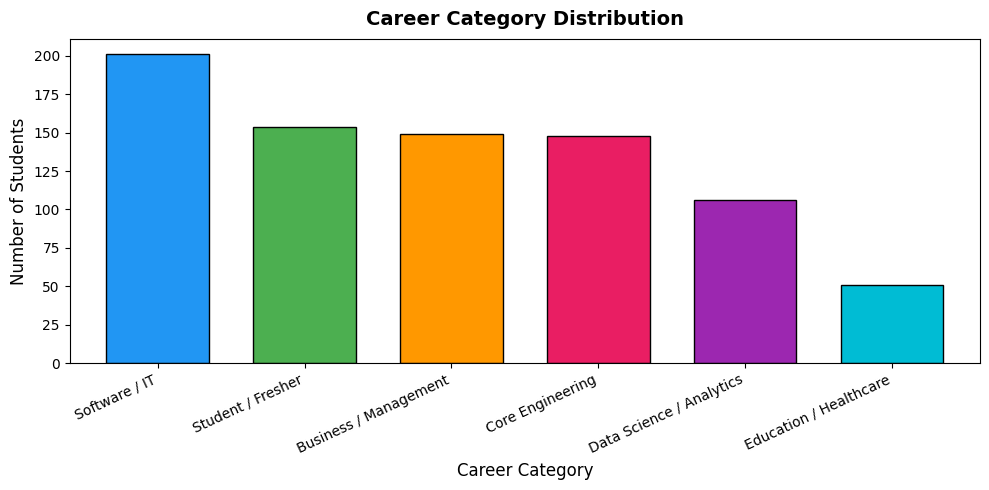

Career distribution chart saved!


In [20]:
plt.figure(figsize=(10, 5))
colors = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0','#00BCD4']
df['Career_Category'].value_counts().plot(
    kind='bar', color=colors, edgecolor='black', width=0.7
)
plt.title('Career Category Distribution', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Career Category', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.xticks(rotation=25, ha='right', fontsize=10)
plt.tight_layout()
plt.savefig('career_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Career distribution chart saved!")

**Clean CGPA Column**

In [21]:
def clean_cgpa(val):
    """Converts CGPA (GPA scale) or percentage to a unified 0–100 scale."""
    try:
        v = float(str(val).strip())
        # GPA out of 10 → convert to percentage
        if v <= 10:
            return v * 10
        return v  # already a percentage
    except:
        return np.nan

df['CGPA_Clean'] = df['CGPA'].apply(clean_cgpa)
df['CGPA_Clean'] = df['CGPA_Clean'].fillna(df['CGPA_Clean'].median())
print(f"CGPA range: {df['CGPA_Clean'].min():.1f} – {df['CGPA_Clean'].max():.1f}")

CGPA range: 0.0 – 98.0


**Skill Keyword Features**

In [23]:
SKILL_KEYWORDS = [
    'python', 'sql', 'java', 'machine learning', 'data',
    'excel', 'communication', 'marketing', 'design',
    'management', 'cloud', 'c++', 'javascript', 'finance',
    'research', 'teaching', 'cad', 'problem solving', 'analytics'
]

for kw in SKILL_KEYWORDS:
    col = 'skill_' + kw.replace(' ', '_').replace('+', 'plus')
    df[col] = df['Skills'].fillna('').str.lower().str.contains(kw, regex=False).astype(int)

print(f"Created {len(SKILL_KEYWORDS)} skill-based binary features")

Created 19 skill-based binary features


**Interest Keyword Features**

In [24]:
INTEREST_KEYWORDS = [
    'technology', 'data', 'business', 'teaching', 'research',
    'finance', 'marketing', 'software', 'engineering', 'medical',
    'science', 'design', 'management'
]

for kw in INTEREST_KEYWORDS:
    col = 'interest_' + kw
    df[col] = df['Interests'].fillna('').str.lower().str.contains(kw, regex=False).astype(int)

print(f"Created {len(INTEREST_KEYWORDS)} interest-based binary features")


Created 13 interest-based binary features


**Encode Categorical Columns**

In [26]:
le_gender = LabelEncoder()
df['Gender_enc'] = le_gender.fit_transform(df['Gender'].fillna('Unknown').str.strip())

le_course = LabelEncoder()
df['UG_Course_enc'] = le_course.fit_transform(df['UG_Course'].fillna('Unknown').str.strip())

df['Has_Cert_enc'] = (df['Has_Certification'].str.upper().str.strip() == 'YES').astype(int)
df['Is_Working_enc'] = (df['Is_Working'].str.upper().str.strip() == 'YES').astype(int)

print(f"Encoded: Gender, UG Course, Certification, Working Status")

Encoded: Gender, UG Course, Certification, Working Status


**Assemble Feature List**

In [28]:
feature_cols = (
    ['CGPA_Clean', 'Gender_enc', 'UG_Course_enc', 'Has_Cert_enc', 'Is_Working_enc']
    + [c for c in df.columns if c.startswith('skill_')]
    + [c for c in df.columns if c.startswith('interest_')]
)
print(f"\n Total features used: {len(feature_cols)}")
print(f"Feature names:\n{feature_cols}")


 Total features used: 37
Feature names:
['CGPA_Clean', 'Gender_enc', 'UG_Course_enc', 'Has_Cert_enc', 'Is_Working_enc', 'skill_python', 'skill_sql', 'skill_java', 'skill_machine_learning', 'skill_data', 'skill_excel', 'skill_communication', 'skill_marketing', 'skill_design', 'skill_management', 'skill_cloud', 'skill_cplusplus', 'skill_javascript', 'skill_finance', 'skill_research', 'skill_teaching', 'skill_cad', 'skill_problem_solving', 'skill_analytics', 'interest_technology', 'interest_data', 'interest_business', 'interest_teaching', 'interest_research', 'interest_finance', 'interest_marketing', 'interest_software', 'interest_engineering', 'interest_medical', 'interest_science', 'interest_design', 'interest_management']


**Build Feature Matrix X & Target y**

In [30]:
X = df[feature_cols].values

# Target vector
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(df['Career_Category'].values)
num_classes = len(le_target.classes_)

print("=" * 55)
print("TARGET CLASSES")
print("=" * 55)
for i, cls in enumerate(le_target.classes_):
    count = (y_encoded == i).sum()
    print(f"  {i}  {cls:<30} ({count} samples)")

TARGET CLASSES
  0  Business / Management          (149 samples)
  1  Core Engineering               (148 samples)
  2  Data Science / Analytics       (106 samples)
  3  Education / Healthcare         (51 samples)
  4  Software / IT                  (201 samples)
  5  Student / Fresher              (154 samples)


**One-Hot Encode & Normalize**

In [32]:
y_onehot = to_categorical(y_encoded, num_classes=num_classes)

# Normalize all features to [0, 1]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print(f"\n Feature matrix shape : {X_scaled.shape}")
print(f" Target matrix shape  : {y_onehot.shape}")


 Feature matrix shape : (809, 37)
 Target matrix shape  : (809, 6)


**Train / Test Split (80:20)**

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_onehot,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded        # preserves class proportions
)

print("=" * 55)
print("TRAIN / TEST SPLIT")
print("=" * 55)
print(f"  Training samples   : {X_train.shape[0]}")
print(f"  Testing samples    : {X_test.shape[0]}")
print(f"  Number of features : {X_train.shape[1]}")
print(f"  Number of classes  : {num_classes}")

TRAIN / TEST SPLIT
  Training samples   : 647
  Testing samples    : 162
  Number of features : 37
  Number of classes  : 6


**Build the ANN Model**

In [35]:
num_features = X_train.shape[1]

model = Sequential([
    # Input + first hidden layer
    Dense(128, activation='relu', input_shape=(num_features,)),
    BatchNormalization(),

    # Second hidden layer
    Dense(64, activation='relu'),
    Dropout(0.3),              # drops 30% neurons to prevent overfitting

    # Third hidden layer
    Dense(32, activation='relu'),
    Dropout(0.2),

    # Output layer — one neuron per career class
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("=" * 55)
print("ANN MODEL ARCHITECTURE")
print("=" * 55)
model.summary()

ANN MODEL ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,910 (62.15 KB)

 Trainable params: 15,654 (61.15 KB)

 Non-trainable params: 256 (1.00 KB)

**Train the Model**

In [37]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

print("=" * 55)
print("TRAINING STARTED...")
print("=" * 55)

history = model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

best_val_acc = max(history.history['val_accuracy'])
best_val_loss = min(history.history['val_loss'])
epochs_run = len(history.history['loss'])

print(f"\n Training complete!")
print(f"   Epochs run              : {epochs_run}")
print(f"   Best Validation Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"   Best Validation Loss    : {best_val_loss:.4f}")

TRAINING STARTED...
Epoch 1/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5899 - loss: 1.1186 - val_accuracy: 0.4538 - val_loss: 1.4793
Epoch 2/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6054 - loss: 1.0597 - val_accuracy: 0.4692 - val_loss: 1.4855
Epoch 3/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5861 - loss: 1.1076 - val_accuracy: 0.4615 - val_loss: 1.5029
Epoch 4/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5687 - loss: 1.0472 - val_accuracy: 0.4692 - val_loss: 1.5389
Epoch 5/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5880 - loss: 1.0338 - val_accuracy: 0.4769 - val_loss: 1.5561
Epoch 6/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6093 - loss: 1.0224 - val_accuracy: 0.4462 - val_loss: 1.5976
Epoch 7/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6480 - loss: 0.9843 - val_accuracy: 0.4538 - val_loss: 1.6376
Epoch 8/150
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6325 - loss: 0.9669 - val_

**Plot Training History**

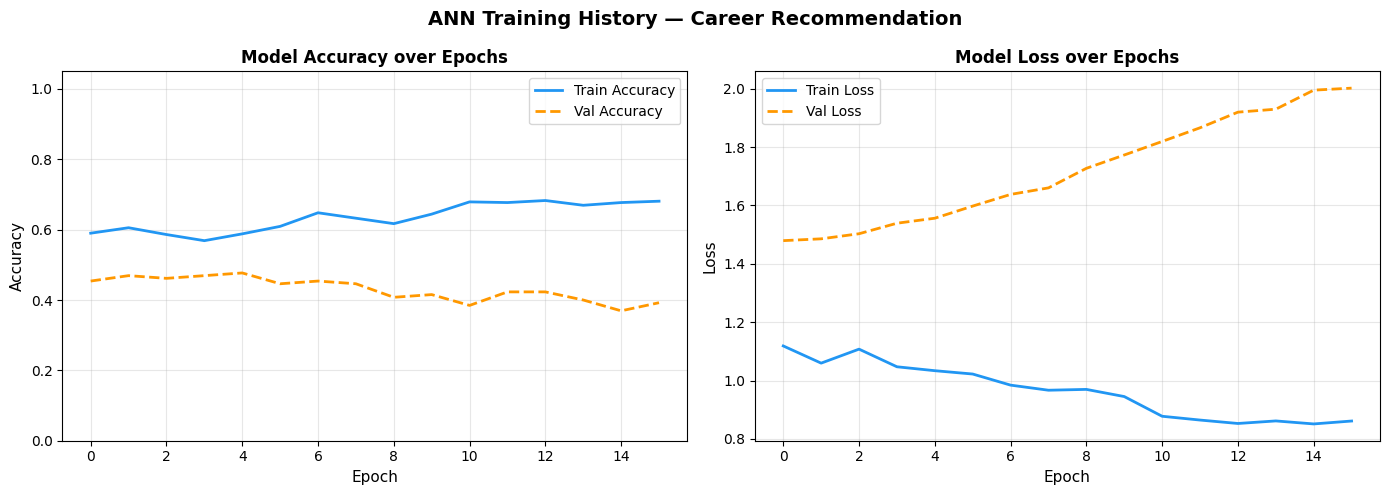

In [46]:
 fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ANN Training History — Career Recommendation', fontsize=14, fontweight='bold')

# ── Accuracy ──────────────────────────────────────────────────
axes[0].plot(history.history['accuracy'],     color='#2196F3', linewidth=2, label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], color='#FF9800', linewidth=2, label='Val Accuracy',   linestyle='--')
axes[0].set_title('Model Accuracy over Epochs', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1.05)

# ── Loss ──────────────────────────────────────────────────────
axes[1].plot(history.history['loss'],     color='#2196F3', linewidth=2, label='Train Loss')
axes[1].plot(history.history['val_loss'], color='#FF9800', linewidth=2, label='Val Loss',   linestyle='--')
axes[1].set_title('Model Loss over Epochs', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Loss', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()


**Evaluate on Test Set**

In [42]:
y_pred_prob = model.predict(X_test)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = np.argmax(y_test, axis=1)

# Overall accuracy
test_acc = accuracy_score(y_true, y_pred)

print("=" * 55)
print("MODEL EVALUATION ON TEST SET")
print("=" * 55)
print(f"\n  ★  Overall Test Accuracy: {test_acc*100:.2f}%  ★\n")

# Full classification report
print("=" * 55)
print("CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(
    y_true, y_pred,
    target_names=le_target.classes_,
    digits=4
))


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
MODEL EVALUATION ON TEST SET

  ★  Overall Test Accuracy: 52.47%  ★

CLASSIFICATION REPORT
                          precision    recall  f1-score   support

   Business / Management     0.4375    0.4667    0.4516        30
        Core Engineering     0.5357    0.5000    0.5172        30
Data Science / Analytics     0.4286    0.1429    0.2143        21
  Education / Healthcare     0.6000    0.6000    0.6000        10
           Software / IT     0.4717    0.6250    0.5376        40
       Student / Fresher     0.6875    0.7097    0.6984        31

                accuracy                         0.5247       162
               macro avg     0.5268    0.5074    0.5032       162
            weighted avg     0.5208    0.5247    0.5106       162



**Confusion Matrix Heatmap**

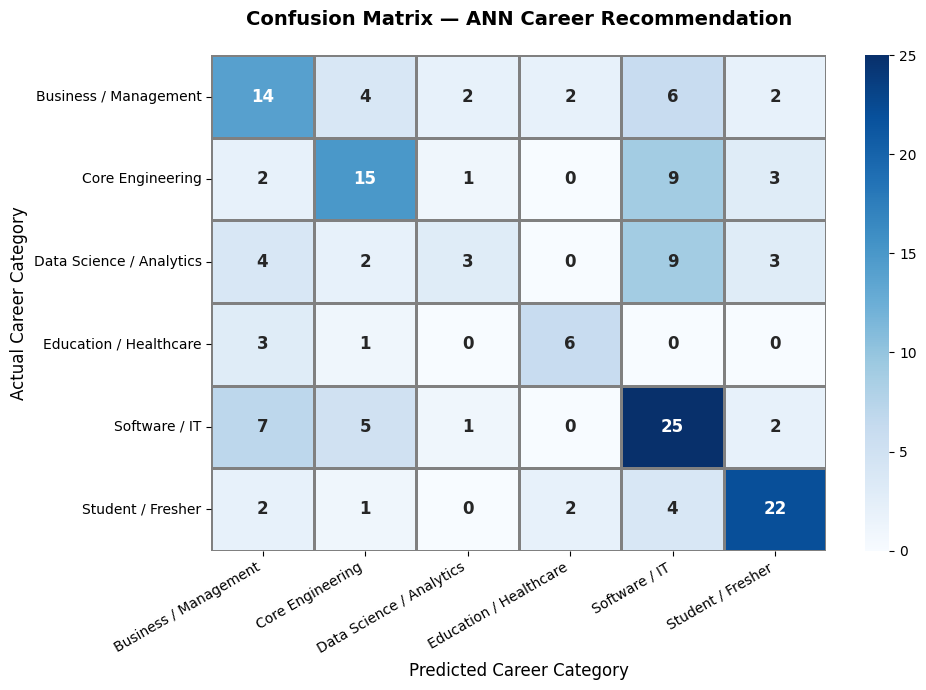

In [47]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le_target.classes_,
    yticklabels=le_target.classes_,
    linewidths=0.8,
    linecolor='gray',
    annot_kws={'size': 12, 'weight': 'bold'}
)
plt.title('Confusion Matrix — ANN Career Recommendation\n', fontsize=14, fontweight='bold')
plt.ylabel('Actual Career Category', fontsize=12)
plt.xlabel('Predicted Career Category', fontsize=12)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

**Per-Class Metrics Bar Chart**

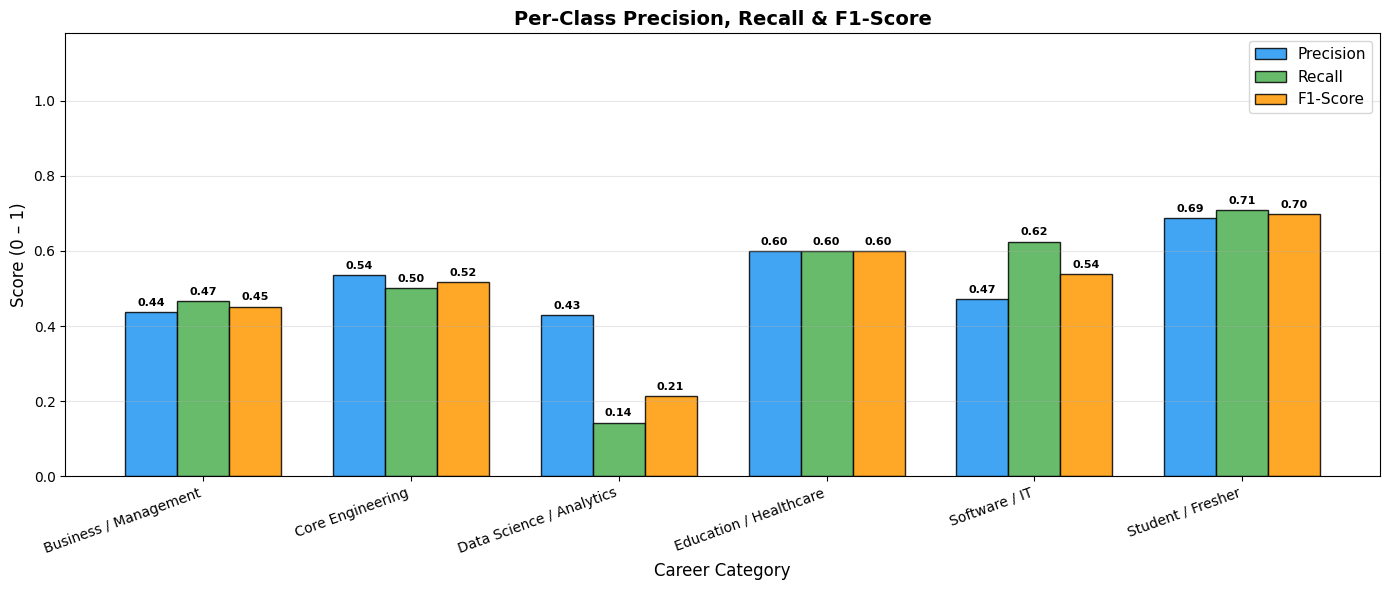

In [44]:
precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, labels=range(num_classes)
)

class_labels = le_target.classes_
x = np.arange(num_classes)
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
b1 = ax.bar(x - width, precision, width, label='Precision', color='#2196F3', alpha=0.85, edgecolor='black')
b2 = ax.bar(x,          recall,   width, label='Recall',    color='#4CAF50', alpha=0.85, edgecolor='black')
b3 = ax.bar(x + width,  f1,       width, label='F1-Score',  color='#FF9800', alpha=0.85, edgecolor='black')

# Value labels on top of each bar
for bars in [b1, b2, b3]:
    for rect in bars:
        h = rect.get_height()
        ax.annotate(f'{h:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, h),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_title('Per-Class Precision, Recall & F1-Score', fontsize=14, fontweight='bold')
ax.set_xlabel('Career Category', fontsize=12)
ax.set_ylabel('Score (0 – 1)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(class_labels, rotation=20, ha='right', fontsize=10)
ax.set_ylim(0, 1.18)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('metrics_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

**Final Results Summary Table**

In [48]:
results_df = pd.DataFrame({
    'Career Category' : le_target.classes_,
    'Precision'       : np.round(precision, 4),
    'Recall'          : np.round(recall,    4),
    'F1-Score'        : np.round(f1,        4),
    'Support'         : support.astype(int)
})

print("=" * 65)
print("FINAL RESULTS SUMMARY TABLE")
print("=" * 65)
print(results_df.to_string(index=False))
print("=" * 65)
print(f"  Overall Test Accuracy : {test_acc*100:.2f}%")
print(f"  Macro Avg Precision   : {precision.mean():.4f}")
print(f"  Macro Avg Recall      : {recall.mean():.4f}")
print(f"  Macro Avg F1-Score    : {f1.mean():.4f}")
print("=" * 65)

FINAL RESULTS SUMMARY TABLE
         Career Category  Precision  Recall  F1-Score  Support
   Business / Management     0.4375  0.4667    0.4516       30
        Core Engineering     0.5357  0.5000    0.5172       30
Data Science / Analytics     0.4286  0.1429    0.2143       21
  Education / Healthcare     0.6000  0.6000    0.6000       10
           Software / IT     0.4717  0.6250    0.5376       40
       Student / Fresher     0.6875  0.7097    0.6984       31
  Overall Test Accuracy : 52.47%
  Macro Avg Precision   : 0.5268
  Macro Avg Recall      : 0.5074
  Macro Avg F1-Score    : 0.5032


**Career Prediction Demo (Part 1)**

In [49]:
print("=" * 65)
print("DEMO: Predict Career for a New Student Profile")
print("=" * 65)

# ── Pick a random student from the test set ───────────────────
idx = 5
sample       = X_test[idx].reshape(1, -1)
actual_label = le_target.classes_[y_true[idx]]
pred_label   = le_target.classes_[y_pred[idx]]
confidence   = y_pred_prob[idx][y_pred[idx]] * 100

print(f"\n  Actual Career    : {actual_label}")
print(f"  Predicted Career : {pred_label}")
print(f"  Confidence       : {confidence:.1f}%")

DEMO: Predict Career for a New Student Profile

  Actual Career    : Business / Management
  Predicted Career : Business / Management
  Confidence       : 57.8%


**Career Prediction Demo (Part 2)**

In [52]:
print(f"\n  Probability Distribution:")
print(f"  {'Career Category':<35} {'Prob %':>7}  Bar")
print(f"  {'─'*60}")
probs = y_pred_prob[idx]
for career, prob in zip(le_target.classes_, probs):
    bar = '█' * int(prob * 25)
    star = '  ◄ PREDICTED' if career == pred_label else ''
    print(f"  {career:<35} {prob*100:6.1f}%  {bar}{star}")

print(f"\n Demo complete!")


  Probability Distribution:
  Career Category                      Prob %  Bar
  ────────────────────────────────────────────────────────────
  Business / Management                 57.8%  ██████████████  ◄ PREDICTED
  Core Engineering                      10.1%  ██
  Data Science / Analytics              10.7%  ██
  Education / Healthcare                 1.3%  
  Software / IT                         16.5%  ████
  Student / Fresher                      3.6%  

 Demo complete!
